## Import Library & Setup Direktori

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

# Membuat folder output jika belum ada
os.makedirs('../data/processed', exist_ok=True)
print("Setup selesai. Lingkungan siap digunakan!")

Setup selesai. Lingkungan siap digunakan!


## Load & Cleaning Data

In [2]:
print("=== Cleaning Dataset Customer Support ===")

# Memuat file dari folder data/raw
file_path = '../data/raw/Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv'
df_chat = pd.read_csv(file_path)

print(f"Bentuk data awal: {df_chat.shape}")

# 1. Menangani nilai kosong (dropna)
# 2. Mengambil kolom yang relevan saja
df_chat = df_chat[['instruction', 'intent', 'response']].dropna()

# 3. Menghapus duplikasi instruksi untuk menghindari model menghafal data (overfitting)
df_chat = df_chat.drop_duplicates(subset=['instruction'])

print(f"Bentuk data setelah dibersihkan: {df_chat.shape}")
display(df_chat.head(3))

=== Cleaning Dataset Customer Support ===
Bentuk data awal: (26872, 5)
Bentuk data setelah dibersihkan: (24635, 3)


,instruction,intent,response
0,question about cancelling order {{Order Number}},cancel_order,I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,cancel_order,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},cancel_order,I can sense that you're seeking assistance wit...


## Exploratory Data Analysis / EDA

=== Exploratory Data Analysis (EDA) ===


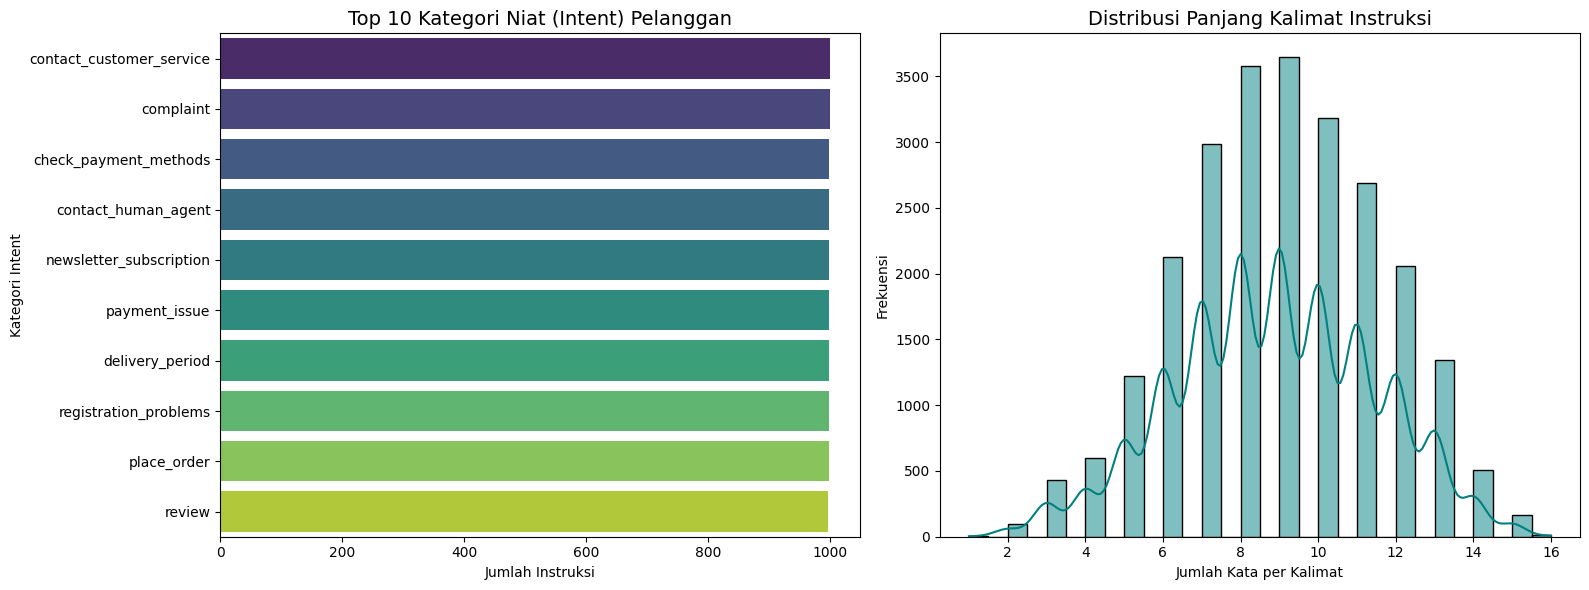

Rata-rata panjang kalimat: 8.86 kata


In [3]:
print("=== Exploratory Data Analysis (EDA) ===")
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Visualisasi 1: Top 10 Intent (Niat Pelanggan)
top_intents = df_chat['intent'].value_counts().head(10)
sns.barplot(x=top_intents.values, y=top_intents.index, palette='viridis', ax=axes[0])
axes[0].set_title('Top 10 Kategori Niat (Intent) Pelanggan', fontsize=14)
axes[0].set_xlabel('Jumlah Instruksi')
axes[0].set_ylabel('Kategori Intent')

# Visualisasi 2: Distribusi Panjang Kalimat (Penting untuk setting memori AI)
df_chat['word_count'] = df_chat['instruction'].apply(lambda x: len(str(x).split()))
sns.histplot(df_chat['word_count'], bins=30, kde=True, color='teal', ax=axes[1])
axes[1].set_title('Distribusi Panjang Kalimat Instruksi', fontsize=14)
axes[1].set_xlabel('Jumlah Kata per Kalimat')
axes[1].set_ylabel('Frekuensi')

plt.tight_layout()
plt.show()

print(f"Rata-rata panjang kalimat: {df_chat['word_count'].mean():.2f} kata")

## Transformasi Data (Prompt Formatting untuk Fine-Tuning LLM)

In [4]:
print("=== Transformasi Format Prompt LLM ===")

# Kita ambil sampel 2.500 data acak agar proses training di komputer lokal Anda tidak memakan waktu berhari-hari
df_train = df_chat.sample(n=2500, random_state=42).copy()

def create_prompt(row):
    # System Prompt: Memberikan "kepribadian" pada bot
    system_msg = "Anda adalah agen Customer Service AI yang empatik, sopan, dan profesional. Selalu berikan panduan yang jelas sesuai kebijakan perusahaan."
    user_msg = row['instruction']
    assistant_msg = row['response']
    
    # Format Standar (ChatML) yang dimengerti oleh LLM seperti Llama / TinyLlama
    prompt = f"<|system|>\n{system_msg}</s>\n<|user|>\n{user_msg}</s>\n<|assistant|>\n{assistant_msg}</s>"
    return prompt

# Menerapkan transformasi ke seluruh data
df_train['text'] = df_train.apply(create_prompt, axis=1)

print("✅ Contoh hasil transformasi data (Prompt):")
print("-" * 50)
print(df_train['text'].iloc[0])
print("-" * 50)

=== Transformasi Format Prompt LLM ===
✅ Contoh hasil transformasi data (Prompt):
--------------------------------------------------
<|system|>
Anda adalah agen Customer Service AI yang empatik, sopan, dan profesional. Selalu berikan panduan yang jelas sesuai kebijakan perusahaan.</s>
<|user|>
I have an issue with the online registration</s>
<|assistant|>
Thank you for trusting to us regarding the issue you encountered with the online registration. We understand that encountering difficulties during the registration process can be frustrating, and we apologize for any inconvenience caused. To better assist you, could you please provide more details about the specific issue you are facing? Any additional information you can provide will help us investigate and resolve the problem effectively. Rest assured that we are committed to ensuring a seamless registration experience for all our users, and your feedback is invaluable in helping us improve our services.</s>
------------------------

## Ekspor Data Siap Latih

In [5]:
# Ekspor ke folder data/processed
output_file = '../data/processed/finetuning_dataset.csv'

# Menyimpan hanya kolom 'text' karena LLM akan membaca teks utuh
df_train[['text']].to_csv(output_file, index=False)

print(f"🎉 Preprocessing Selesai! Data siap latih telah disimpan di: {output_file}")

🎉 Preprocessing Selesai! Data siap latih telah disimpan di: ../data/processed/finetuning_dataset.csv
